In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

In [6]:
data=pd.read_csv("data/data.csv")
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
data.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
data.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
data.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [16]:
print("Categories in ' gender' variable:", end=" " )
print(data["gender"].unique ())

print("Categories in ' race/ethnicity' variable: ",end=" ")
print(data["race_ethnicity"].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(data["parental_level_of_education"].unique())

print("Categories in 'lunch' variable:", end=" ")
print(data["lunch"].unique())

print("Categories in 'test preparation course' variable:", end=" ")
print(data["test_preparation_course"].unique())


Categories in ' gender' variable: ['female' 'male']
Categories in ' race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test preparation course' variable: ['none' 'completed']


In [19]:
numeric= [numeric_cols for numeric_cols in data.columns if data[numeric_cols].dtype!="object"]
categoric= [categoric_cols for categoric_cols in data.columns if data[categoric_cols].dtype=="object"]

In [20]:
print(f"length of numeric columns: {len(numeric)} , features: {numeric}")
print(f"length of categorical columns: {len(categoric)} , features: {categoric}")

length of numeric columns: 3 , features: ['math_score', 'reading_score', 'writing_score']
length of categorical columns: 5 , features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [21]:
data["total_score"]=data["math_score"]+data["reading_score"]+data["writing_score"]
data["average_score"]=data["total_score"]/3

In [22]:
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [23]:
reading_full = data[data["reading_score"] == 100]["average_score"].count()
writing_full = data[data["writing_score"] == 100]["average_score"].count()
math_full = data[data["math_score"] == 100]["average_score"].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [24]:
reading_less_20 = data[data['reading_score'] <= 20]['average_score'].count()
writing_less_20 = data[data['writing_score'] < 20]['average_score'].count()
math_less_20 = data[data['math_score'] <= 20]['average_score'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


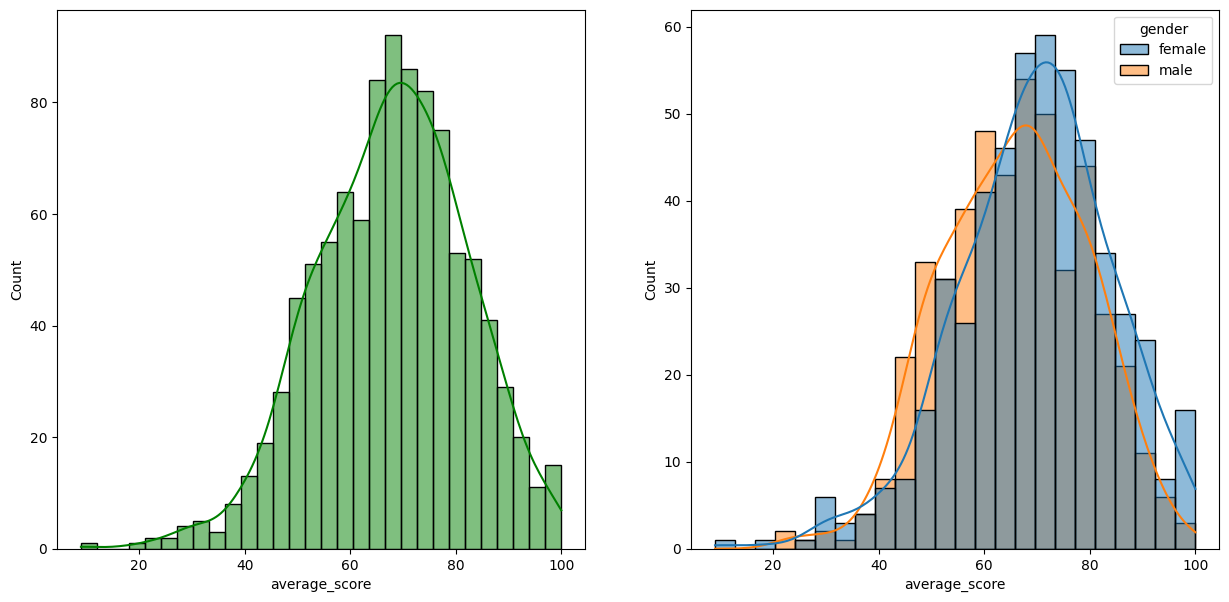

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot (data=data,x='average_score',bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=data,x='average_score' ,kde=True,hue="gender")
plt. show()

In [34]:
data.corr(numeric_only=True)["average_score"]

math_score       0.918746
reading_score    0.970331
writing_score    0.965667
total_score      1.000000
average_score    1.000000
Name: average_score, dtype: float64

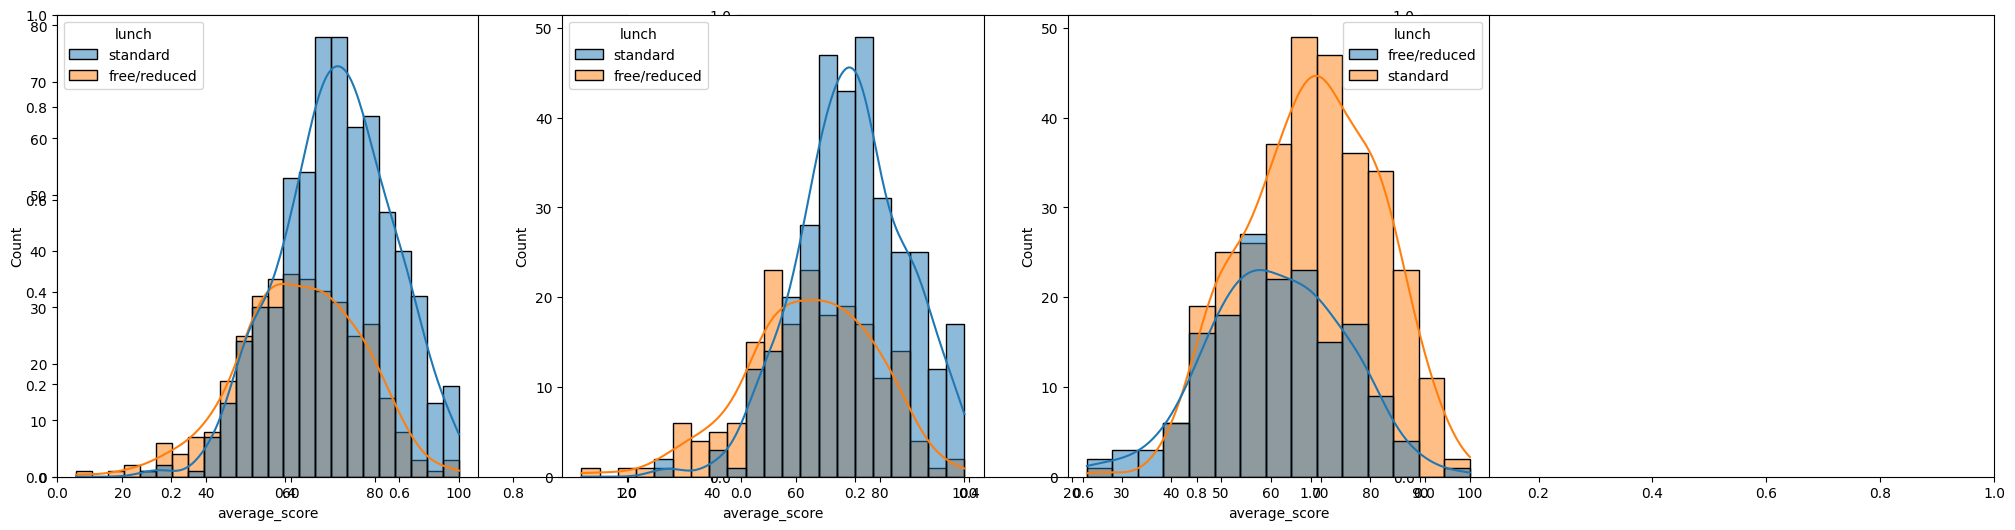

In [37]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=data,x='average_score' ,kde=True,hue="lunch")
plt.subplot(142)
sns.histplot(data=data[data.gender == 'female'],x='average_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=data[data.gender == 'male' ],x='average_score',kde=True, hue='lunch')
plt. show()